<a href="https://colab.research.google.com/github/Ali-Sharafeddine/FCS_Assignments/blob/main/FineTuning_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -f AirlineTweets.csv

!wget -O AirlineTweets.csv \
"https://www.dropbox.com/s/lkd0eklmi64m9xm/AirlineTweets.csv?dl=1"

--2026-09-11 18:22:14--  https://www.dropbox.com/s/lkd0eklmi64m9xm/AirlineTweets.csv?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/095miuq8of1pgai5br97j/AirlineTweets.csv?rlkey=elr0jere7dsutxl41781w9s8c&dl=1 [following]
--2026-09-11 18:22:14--  https://www.dropbox.com/scl/fi/095miuq8of1pgai5br97j/AirlineTweets.csv?rlkey=elr0jere7dsutxl41781w9s8c&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uccf1f5dfe8c60c19d0060d74284.dl.dropboxusercontent.com/cd/0/inline/DH-9g7rdwLdsO0WcfEPdJ-P6apiMwYy0nzqYF7TEQhngwyI3WphfHSyIx1TJ59Ac-Oy71MwuGUIX-GAUX-5yXaZ_B8jnx3tlXdv6pOe0xdar3YMxB707bkluefA7yvRzTOL0M5WH59Ot5YFNHjYyZ_kL/file?dl=1# [following]
--2026-09-11 18:22:14--  https://uccf1f5dfe8c60c19d0060d74284.d

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("AirlineTweets.csv")

In [ ]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
df = df[['airline_sentiment', 'text']]

In [ ]:
df

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...
...,...,...
14635,positive,@AmericanAir thank you we got on a different f...
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,@AmericanAir Please bring American Airlines to...
14638,negative,"@AmericanAir you have my money, you change my ..."


<Axes: >

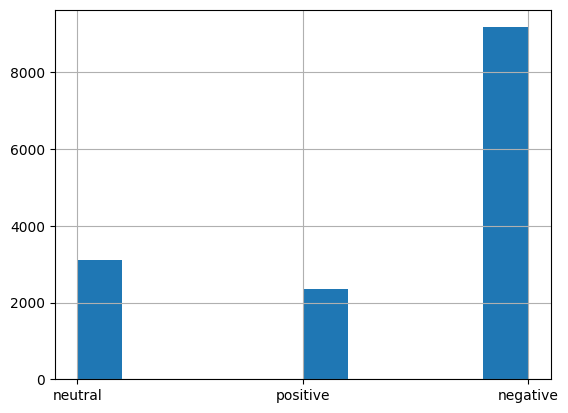

In [ ]:
df['airline_sentiment'].hist()

In [ ]:
target_map = { 'positive': 1, 'negative': 0, 'neutral': 2}
df['target'] = df['airline_sentiment'].map(target_map)

In [ ]:
df

,airline_sentiment,text,target
0,neutral,@VirginAmerica What @dhepburn said.,2
1,positive,@VirginAmerica plus you've added commercials t...,1
2,neutral,@VirginAmerica I didn't today... Must mean I n...,2
3,negative,@VirginAmerica it's really aggressive to blast...,0
4,negative,@VirginAmerica and it's a really big bad thing...,0
...,...,...,...
14635,positive,@AmericanAir thank you we got on a different f...,1
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...,0
14637,neutral,@AmericanAir Please bring American Airlines to...,2
14638,negative,"@AmericanAir you have my money, you change my ...",0


In [ ]:
df1 = df[['text','target']]
df1.columns = ['sentence','label']
df1.to_csv('data.csv', index = False)

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
raw_dataset = load_dataset("csv", data_files = 'data.csv')

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 14640
    })
})

In [ ]:
split = raw_dataset['train'].train_test_split(test_size=0.3, seed=42)

In [ ]:
split

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 10248
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 4392
    })
})

In [ ]:
# Import AutoTokenizer and create tokenizer object
from transformers import AutoTokenizer
checkpoint = 'bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
def tokenize_fn(batch):
  return tokenizer(batch['sentence'], truncation = True)

In [ ]:
tokenized_dataset = split.map(tokenize_fn, batched = True)

Map:   0%|          | 0/10248 [00:00<?, ? examples/s]

Map:   0%|          | 0/4392 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels = 3)

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                  Param #
BertForSequenceClassification                           --
├─BertModel: 1-1                                        --
│    └─BertEmbeddings: 2-1                              --
│    │    └─Embedding: 3-1                              22,268,928
│    │    └─Embedding: 3-2                              393,216
│    │    └─Embedding: 3-3                              1,536
│    │    └─LayerNorm: 3-4                              1,536
│    │    └─Dropout: 3-5                                --
│    └─BertEncoder: 2-2                                 --
│    │    └─ModuleList: 3-6                             85,054,464
│    └─BertPooler: 2-3                                  --
│    │    └─Linear: 3-7                                 590,592
│    │    └─Tanh: 3-8                                   --
├─Dropout: 1-2                                          --
├─Linear: 1-3                                           2,307
Total params: 10

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="training_dir",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
)

In [ ]:
def compute_metrics(logits_and_labels):
  logits, labels = logits_and_labels
  predictions = np.argmax(logits, axis=-1)
  acc = np.mean(predictions == labels)
  f1 = f1_score(labels, predictions, average = 'micro')
  return {'accuracy': acc, 'f1_score': f1}

In [ ]:
trainer = Trainer(
    model,
    training_args,
    train_dataset = tokenized_dataset['train'],
    eval_dataset = tokenized_dataset['test'],
    processing_class = tokenizer,
    compute_metrics=compute_metrics
    )

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.533973,0.459776,0.834016,0.834016
2,0.323590,0.476144,0.841530,0.841530
3,0.210206,0.675974,0.839481,0.839481


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1923, training_loss=0.3039837885324495, metrics={'train_runtime': 399.5755, 'train_samples_per_second': 76.942, 'train_steps_per_second': 4.813, 'total_flos': 771719876490528.0, 'train_loss': 0.3039837885324495, 'epoch': 3.0})

In [ ]:
! ls training_dir

checkpoint-1282  checkpoint-1923  checkpoint-641


In [ ]:
from transformers import pipeline

In [ ]:
saved_model = pipeline('text-classification',
                       model = 'training_dir/checkpoint-1282')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
test_texts = list(split["test"]["sentence"])

predictions = saved_model(
    test_texts,
    batch_size=64,
    truncation=True
)

In [ ]:
predictions

[{'label': 'LABEL_1', 'score': 0.8868873715400696},
 {'label': 'LABEL_1', 'score': 0.9306970238685608},
 {'label': 'LABEL_0', 'score': 0.4351723790168762},
 {'label': 'LABEL_1', 'score': 0.4902825653553009},
 {'label': 'LABEL_2', 'score': 0.37981685996055603},
 {'label': 'LABEL_0', 'score': 0.9979044198989868},
 {'label': 'LABEL_2', 'score': 0.8983481526374817},
 {'label': 'LABEL_2', 'score': 0.8380945324897766},
 {'label': 'LABEL_1', 'score': 0.579850971698761},
 {'label': 'LABEL_0', 'score': 0.9982477426528931},
 {'label': 'LABEL_0', 'score': 0.985585629940033},
 {'label': 'LABEL_0', 'score': 0.9979029893875122},
 {'label': 'LABEL_1', 'score': 0.9144706726074219},
 {'label': 'LABEL_0', 'score': 0.9976394176483154},
 {'label': 'LABEL_2', 'score': 0.9641318917274475},
 {'label': 'LABEL_2', 'score': 0.42111092805862427},
 {'label': 'LABEL_0', 'score': 0.9276667237281799},
 {'label': 'LABEL_0', 'score': 0.9981422424316406},
 {'label': 'LABEL_0', 'score': 0.9935663342475891},
 {'label': '

In [ ]:
predictions[:10]

[{'label': 'LABEL_1', 'score': 0.8868873715400696},
 {'label': 'LABEL_1', 'score': 0.9306970238685608},
 {'label': 'LABEL_0', 'score': 0.4351723790168762},
 {'label': 'LABEL_1', 'score': 0.4902825653553009},
 {'label': 'LABEL_2', 'score': 0.37981685996055603},
 {'label': 'LABEL_0', 'score': 0.9979044198989868},
 {'label': 'LABEL_2', 'score': 0.8983481526374817},
 {'label': 'LABEL_2', 'score': 0.8380945324897766},
 {'label': 'LABEL_1', 'score': 0.579850971698761},
 {'label': 'LABEL_0', 'score': 0.9982477426528931}]

In [ ]:
split["test"]["sentence"][:10]

['@JetBlue thank you!',
 '@united thanks',
 "@SouthwestAir Thank you. The email about RR pts &amp; how to gain more wasn't clear so all of mine r gone. Anything u can do is appreciated.",
 "@AmericanAir Yes, thanks I found those, didn't see the gray tab at first :)",
 "@SouthwestAir my bday was yesterday and my girl gave birth to my first born and I couldn't get a courtesy flight change from Lynn... THANKS!",
 '@united spends 20 minutes beating up a lady about her bag fees.  Random stranger comes up and pays the fee.  #Randomactsofcorporategreed',
 '@VirginAmerica @TTINAC11 I DM you',
 '@united 4 people MCI to DEL. Preferably with Jet Airways EWR-BRU-DEL segment. Anytime in December',
 '@SouthwestAir Deborah helped me💁',
 '@JetBlue Got flight reschedule to flight form PIT to FLL and our flight had mechanical problems so we were delayed an hour Missed my connect']